# Phase 3 — K-Means Clustering

This notebook will:
1. Load Phase 2 processed datasets (X_train, X_val, X_test)  
2. Restrict features to the seven lifestyle habits only  
3. Search for the optimal number of clusters (silhouette and elbow methods)  
4. Fit the final K-Means model on X_train using the chosen k  
5. Assign cluster labels to train, validation, and test sets  
6. Generate cluster profiles showing mean values for each lifestyle habit  
7. Visualize clusters through bar charts and PCA 2D scatter plots  
8. Save labeled datasets and the trained K-Means model for future phases


In [1]:
# --- Phase 3: Setup (dependencies and paths) ---
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Inline plotting for notebooks
%matplotlib inline

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Random state for reproducibility
RANDOM_STATE = 42

# Directory setup
NOTEBOOK_DIR = Path.cwd()
BASE_DIR = NOTEBOOK_DIR.parent
OUTPUTS_DIR = BASE_DIR / "outputs"
ARTIFACTS_DIR = OUTPUTS_DIR / "artifacts"

# Ensure necessary folders exist
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Phase 2 output files
X_TRAIN_FP = OUTPUTS_DIR / "X_train.csv"
X_VAL_FP   = OUTPUTS_DIR / "X_val.csv"
X_TEST_FP  = OUTPUTS_DIR / "X_test.csv"
Y_TRAIN_FP = OUTPUTS_DIR / "y_train.csv"
Y_VAL_FP   = OUTPUTS_DIR / "y_val.csv"
Y_TEST_FP  = OUTPUTS_DIR / "y_test.csv"
FEATS_FP   = OUTPUTS_DIR / "feature_columns.csv"

# Check all files exist
for fp in [X_TRAIN_FP, X_VAL_FP, X_TEST_FP, Y_TRAIN_FP, Y_VAL_FP, Y_TEST_FP, FEATS_FP]:
    if not fp.exists():
        raise FileNotFoundError(f"Missing file: {fp}")

print("Paths and environment ready")
print(f"Base directory : {BASE_DIR}")
print(f"Outputs folder : {OUTPUTS_DIR}")
print(f"Artifacts path : {ARTIFACTS_DIR}")


Paths and environment ready
Base directory : /Users/rykelle/Documents/GitHub/Thesis
Outputs folder : /Users/rykelle/Documents/GitHub/Thesis/outputs
Artifacts path : /Users/rykelle/Documents/GitHub/Thesis/outputs/artifacts


In [2]:
# --- Phase 3: Load processed data and sanity check ---

# Load preprocessed datasets from Phase 2
X_train = pd.read_csv(X_TRAIN_FP)
X_val   = pd.read_csv(X_VAL_FP)
X_test  = pd.read_csv(X_TEST_FP)

y_train = pd.read_csv(Y_TRAIN_FP)
y_val   = pd.read_csv(Y_VAL_FP)
y_test  = pd.read_csv(Y_TEST_FP)

# Restrict to the seven lifestyle habits only
lifestyle_cols = [
    "Sleep_Hours",
    "Work_Hours",
    "Physical_Activity_Hours",
    "Social_Media_Usage",
    "Diet_Quality",
    "Smoking_Habit",
    "Alcohol_Consumption"
]

X_train = X_train[lifestyle_cols].copy()
X_val   = X_val[lifestyle_cols].copy()
X_test  = X_test[lifestyle_cols].copy()

print("Using only lifestyle habit features:")
print(lifestyle_cols)
print()

print("Dataset shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

# Preview data
display(X_train.head())

# Check for missing values
print("Missing values per column:")
print(X_train.isna().sum())

# Confirm scaling range
print("\nSummary statistics (should be scaled 0–1):")
display(X_train.describe().T.round(3))


Using only lifestyle habit features:
['Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours', 'Social_Media_Usage', 'Diet_Quality', 'Smoking_Habit', 'Alcohol_Consumption']

Dataset shapes:
X_train: (35000, 7)
X_val:   (10000, 7)
X_test:  (5000, 7)


,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption
0,0.383333,0.56,0.9,0.127273,0,1,1
1,0.316667,0.64,0.8,0.818182,0,3,3
2,0.883333,0.04,0.6,0.490909,2,2,2
3,0.433333,0.66,1.0,0.254545,1,0,2
4,0.816667,0.06,0.9,0.163636,0,3,3


Missing values per column:
Sleep_Hours                0
Work_Hours                 0
Physical_Activity_Hours    0
Social_Media_Usage         0
Diet_Quality               0
Smoking_Habit              0
Alcohol_Consumption        0
dtype: int64

Summary statistics (should be scaled 0–1):


,count,mean,std,min,25%,50%,75%,max
Sleep_Hours,35000.0,0.502,0.289,0.0,0.250,0.500,0.750,1.0
Work_Hours,35000.0,0.501,0.294,0.0,0.240,0.500,0.760,1.0
Physical_Activity_Hours,35000.0,0.497,0.316,0.0,0.200,0.500,0.800,1.0
Social_Media_Usage,35000.0,0.500,0.289,0.0,0.255,0.509,0.745,1.0
Diet_Quality,35000.0,0.996,0.816,0.0,0.000,1.000,2.000,2.0
Smoking_Habit,35000.0,1.486,1.119,0.0,0.000,1.000,2.000,3.0
Alcohol_Consumption,35000.0,1.504,1.118,0.0,1.000,2.000,3.000,3.0


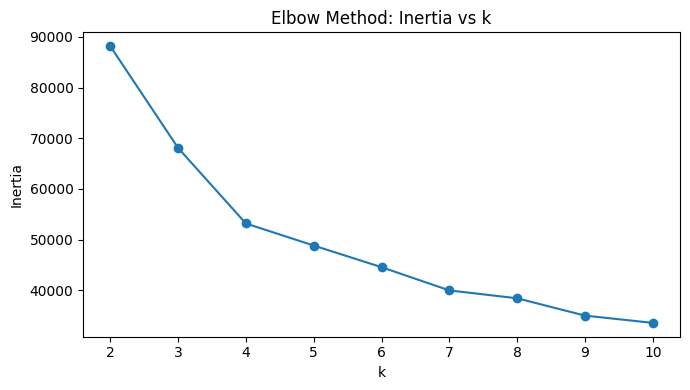

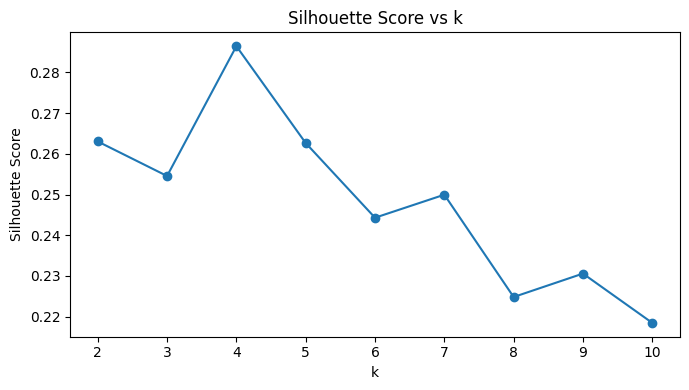

,k,inertia,silhouette
0,2,88158.383247,0.263031
1,3,68082.542255,0.254546
2,4,53186.907309,0.286446
3,5,48839.299137,0.262645
4,6,44568.738188,0.244298
5,7,39990.766874,0.249953
6,8,38435.144610,0.224818
7,9,35018.706733,0.230574
8,10,33586.649453,0.218460


In [3]:
# --- Phase 3: Determine optimal number of clusters (k) ---

K_RANGE = range(2, 11)
inertia_scores = []
silhouette_scores = []

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_train)  # X_train already restricted to the 7 lifestyle features
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train, kmeans.labels_))

# Elbow plot (inertia)
plt.figure(figsize=(7, 4))
plt.plot(list(K_RANGE), inertia_scores, marker='o')
plt.title('Elbow Method: Inertia vs k')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

# Silhouette plot
plt.figure(figsize=(7, 4))
plt.plot(list(K_RANGE), silhouette_scores, marker='o')
plt.title('Silhouette Score vs k')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# Tabular view
score_df = pd.DataFrame({
    'k': list(K_RANGE),
    'inertia': inertia_scores,
    'silhouette': silhouette_scores
}).round(6)

display(score_df)


### Interpreting the Elbow and Silhouette Results

**Elbow Method**
- Inertia dropped sharply from k = 2 to k = 4, then started to flatten.
- This indicates that adding more clusters beyond 4 gives only small improvements.
- The "elbow point" is around **k = 4**, suggesting four clusters is an efficient choice.

**Silhouette Score**
- The silhouette score measures how well-separated the clusters are (higher is better).
- The highest score occurs at **k = 4**, meaning this value gives the best cluster quality and separation.
- Scores decline after k = 4, showing that adding more clusters does not improve structure.

**Conclusion**
- Both the Elbow and Silhouette methods support **k = 4** as the optimal number of clusters.
- The next step is to fit the final K-Means model using **k = 4**.


In [4]:
# --- Phase 3: Fit final K-Means model and assign cluster labels ---

BEST_K = 4  # chosen from elbow and silhouette results

# Fit model on training set only
final_kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=10)
final_kmeans.fit(X_train)

# Assign clusters
X_train['cluster'] = final_kmeans.labels_
X_val['cluster']   = final_kmeans.predict(X_val)
X_test['cluster']  = final_kmeans.predict(X_test)

print("K-Means model trained successfully")
print(f"Number of clusters: {BEST_K}")
print("\nCluster distribution in training set:")
print(X_train['cluster'].value_counts().sort_index())

# Preview labeled training data
display(X_train.head())

# Save labeled data and model for next phase
X_train.to_csv(OUTPUTS_DIR / "X_train_with_clusters.csv", index=False)
X_val.to_csv(OUTPUTS_DIR / "X_val_with_clusters.csv", index=False)
X_test.to_csv(OUTPUTS_DIR / "X_test_with_clusters.csv", index=False)

import joblib
joblib.dump(final_kmeans, ARTIFACTS_DIR / "kmeans_model.pkl")

print("\nFiles saved:")
print(" - X_train_with_clusters.csv")
print(" - X_val_with_clusters.csv")
print(" - X_test_with_clusters.csv")
print(" - kmeans_model.pkl")


K-Means model trained successfully
Number of clusters: 4

Cluster distribution in training set:
cluster
0    8827
1    8593
2    8859
3    8721
Name: count, dtype: int64


,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption,cluster
0,0.383333,0.56,0.9,0.127273,0,1,1,2
1,0.316667,0.64,0.8,0.818182,0,3,3,3
2,0.883333,0.04,0.6,0.490909,2,2,2,3
3,0.433333,0.66,1.0,0.254545,1,0,2,0
4,0.816667,0.06,0.9,0.163636,0,3,3,3



Files saved:
 - X_train_with_clusters.csv
 - X_val_with_clusters.csv
 - X_test_with_clusters.csv
 - kmeans_model.pkl


Cluster profiles (means of lifestyle habits):


,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption,count
cluster,,,,,,,,
0,0.503,0.504,0.499,0.501,0.990,0.496,2.498,8827
1,0.494,0.499,0.500,0.506,0.976,2.499,0.505,8593
2,0.505,0.502,0.495,0.498,1.009,0.497,0.497,8859
3,0.506,0.498,0.495,0.496,1.009,2.496,2.502,8721


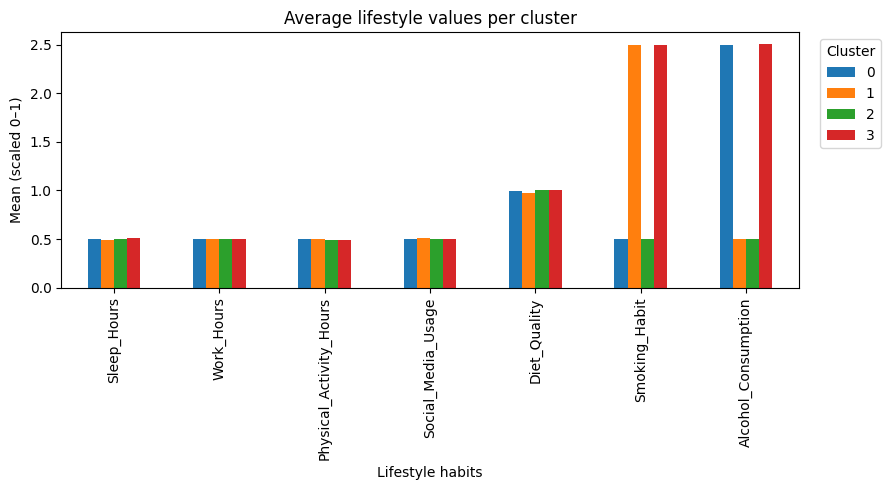

In [5]:
# --- Phase 3: Cluster profiling (mean of lifestyle habits per cluster) ---

# Ensure we use only the lifestyle columns (defined earlier)
lifestyle_cols = [
    "Sleep_Hours",
    "Work_Hours",
    "Physical_Activity_Hours",
    "Social_Media_Usage",
    "Diet_Quality",
    "Smoking_Habit",
    "Alcohol_Consumption"
]

# Table of per-cluster means
cluster_profiles = (
    X_train.groupby("cluster")[lifestyle_cols]
    .mean()
    .round(3)
)

# Add counts per cluster
counts = X_train["cluster"].value_counts().sort_index()
cluster_profiles["count"] = counts.values

print("Cluster profiles (means of lifestyle habits):")
display(cluster_profiles)

# Bar chart of per-cluster means
ax = cluster_profiles[lifestyle_cols].T.plot(kind="bar", figsize=(9,5))
ax.set_title("Average lifestyle values per cluster")
ax.set_xlabel("Lifestyle habits")
ax.set_ylabel("Mean (scaled 0–1)")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
